In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"  # Use raw string to handle Windows file paths
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize the text data
max_words = 5000  # Maximum number of words in the vocabulary
max_len = 10      # Maximum sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(data[text_column])
X = tokenizer.texts_to_sequences(data[text_column])
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')

y = data[target_column]

# Step 2: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train Word2Vec model or load pre-trained model
# Tokenize text for Word2Vec
tokenized_text = [text.split() for text in data[text_column]]  # Split text into words

# Train a Word2Vec model (adjust parameters as necessary)
word2vec_model = Word2Vec(sentences=tokenized_text, vector_size=100, window=5, min_count=1, workers=4)

# Step 4: Prepare Word2Vec embedding matrix
embedding_dim = 100
embedding_matrix = np.zeros((max_words, embedding_dim))

# Populate the embedding matrix with Word2Vec vectors
for word, index in tokenizer.word_index.items():
    if index < max_words:
        try:
            embedding_vector = word2vec_model.wv[word]
            embedding_matrix[index] = embedding_vector
        except KeyError:
            continue  # If the word isn't in Word2Vec model

# Step 5: Build the LSTM model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len, weights=[embedding_matrix], trainable=False),
    SpatialDropout1D(0.2),  # Optional dropout to prevent overfitting
    LSTM(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 6: Train the LSTM model
print("Training LSTM Model...")
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Step 7: Evaluate the LSTM model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"LSTM Test Accuracy: {accuracy * 100:.2f}%")

# Step 8: Save the trained LSTM model
model_path = r"C:\Users\PC\Downloads\LSTM_word2vec_model.h5"  # File path to save the model
model.save(model_path)
print(f"Trained LSTM model saved to {model_path}")

# Step 9: Make predictions and calculate additional metrics
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Calculate accuracy, precision, recall, and F1 score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")

# Step 10: Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Training LSTM Model...
Epoch 1/10


C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


4641/4641 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.8621 - loss: 0.3192 - val_accuracy: 0.9097 - val_loss: 0.2225
Epoch 2/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.9074 - loss: 0.2289 - val_accuracy: 0.9125 - val_loss: 0.2169
Epoch 3/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.9139 - loss: 0.2131 - val_accuracy: 0.9167 - val_loss: 0.2093
Epoch 4/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.9176 - loss: 0.2051 - val_accuracy: 0.9165 - val_loss: 0.2064
Epoch 5/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.9206 - loss: 0.1985 - val_accuracy: 0.9167 - val_loss: 0.2066
Epoch 6/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.9233 - loss: 0.1921 - val_accuracy: 0.9174 - val_loss: 0.2073
Epoch 7/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.9252 - loss: 0.1893 - val_accuracy: 0.9172 - val_loss: 0.2062
Epoch 8/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.9258 - loss: 0.1857 - val

LSTM Test Accuracy: 91.98%
Trained LSTM model saved to C:\Users\PC\Downloads\LSTM_word2vec_model.h5
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
Accuracy: 91.98%
Precision: 92.14%
Recall: 91.77%
F1 Score: 91.95%
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     23238
           1       0.92      0.92      0.92     23171

    accuracy                           0.92     46409
   macro avg       0.92      0.92      0.92     46409
weighted avg       0.92      0.92      0.92     46409



1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


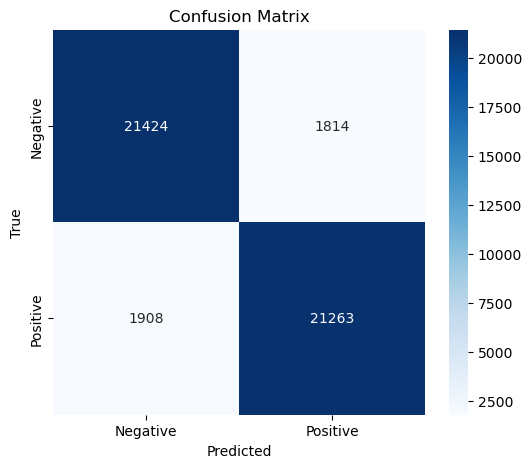

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step: Make predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix using seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


1451/1451 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


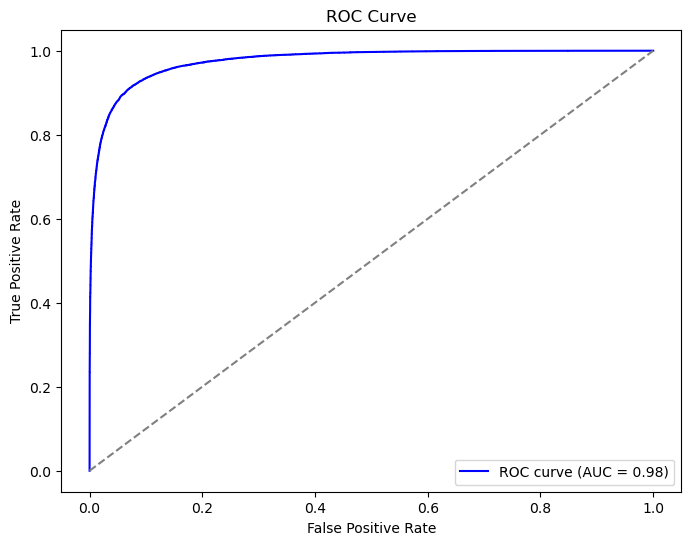

In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step: Make predictions (probabilities for ROC curve)
y_pred_prob = model.predict(X_test)  # This returns probabilities for each class

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random classifier)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


Training LSTM model with Word2Vec embeddings...


C:\Users\PC\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.8770 - loss: 0.2955 - val_accuracy: 0.9098 - val_loss: 0.2190
Epoch 2/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.9189 - loss: 0.2055 - val_accuracy: 0.9159 - val_loss: 0.2083
Epoch 3/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.9260 - loss: 0.1865 - val_accuracy: 0.9140 - val_loss: 0.2092
Epoch 4/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - accuracy: 0.9320 - loss: 0.1710 - val_accuracy: 0.9163 - val_loss: 0.2090
Epoch 5/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.9390 - loss: 0.1560 - val_accuracy: 0.9138 - val_loss: 0.2173
Epoch 6/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.9436 - loss: 0.1449 - val_accuracy: 0.9117 - val_loss: 0.2233
Epoch 7/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.9485 - loss: 0.1320 - val_accuracy: 0.9106 - val_loss: 0.2352
Epoch 8/10
4641/4641 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - accuracy: 0.9543 - loss: 0

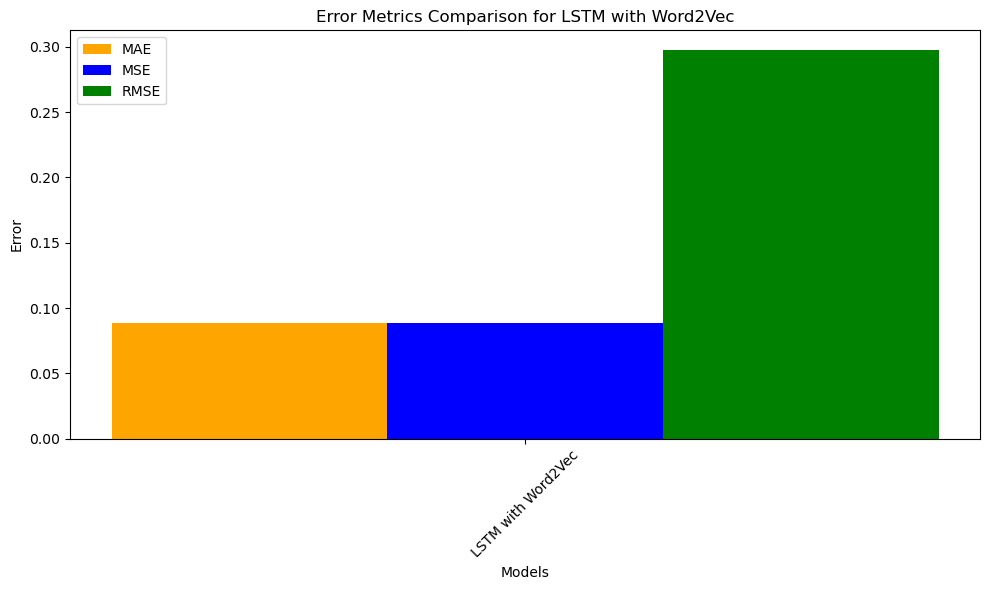

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec

# Dictionary to store error metrics
error_metrics = {}

# Assuming you have pre-trained Word2Vec model
# You can train the Word2Vec model if you don't have a pre-trained one
# Example: word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

# Example of loading a pre-trained Word2Vec model
# word2vec_model = Word2Vec.load("path_to_your_pretrained_word2vec_model")

# Tokenize the text and create a tokenizer
max_words = 5000
max_len = 10

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(data[text_column])  # Assuming `data[text_column]` is your text column
X = tokenizer.texts_to_sequences(data[text_column])
X = pad_sequences(X, maxlen=max_len, padding='post', truncating='post')
y = data[target_column]

# Create Word2Vec embedding matrix
embedding_dim = 100  # Example dimension of Word2Vec embeddings
word_index = tokenizer.word_index
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))

for word, i in word_index.items():
    try:
        # Assuming you have a Word2Vec model trained or loaded
        embedding_vector = word2vec_model.wv[word]
        embedding_matrix[i] = embedding_vector
    except KeyError:
        embedding_matrix[i] = np.zeros(embedding_dim)

# Initialize and train the LSTM model with Word2Vec embeddings
print("Training LSTM model with Word2Vec embeddings...")
model = Sequential([
    Embedding(input_dim=len(word_index) + 1, output_dim=embedding_dim, input_length=max_len, weights=[embedding_matrix], trainable=False),
    LSTM(64, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # For binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Predict on the test set
y_pred_lstm = (model.predict(X_test) > 0.5).astype("int32")

# Calculate error metrics
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
mse_lstm = mean_squared_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mse_lstm)

# Store error metrics
error_metrics["LSTM with Word2Vec"] = {"MAE": mae_lstm, "MSE": mse_lstm, "RMSE": rmse_lstm}

# Print metrics
print(f"LSTM with Word2Vec MAE: {mae_lstm:.4f}, MSE: {mse_lstm:.4f}, RMSE: {rmse_lstm:.4f}")

# Plot the error metrics
mae_values = [metrics["MAE"] for metrics in error_metrics.values()]
mse_values = [metrics["MSE"] for metrics in error_metrics.values()]
rmse_values = [metrics["RMSE"] for metrics in error_metrics.values()]
model_names = list(error_metrics.keys())

x = np.arange(len(model_names))
width = 0.25

# Create the bar plot for error metrics comparison
plt.figure(figsize=(10, 6))
plt.bar(x - width, mae_values, width, label='MAE', color='orange')
plt.bar(x, mse_values, width, label='MSE', color='blue')
plt.bar(x + width, rmse_values, width, label='RMSE', color='green')

plt.xlabel('Models')
plt.ylabel('Error')
plt.title('Error Metrics Comparison for LSTM with Word2Vec')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


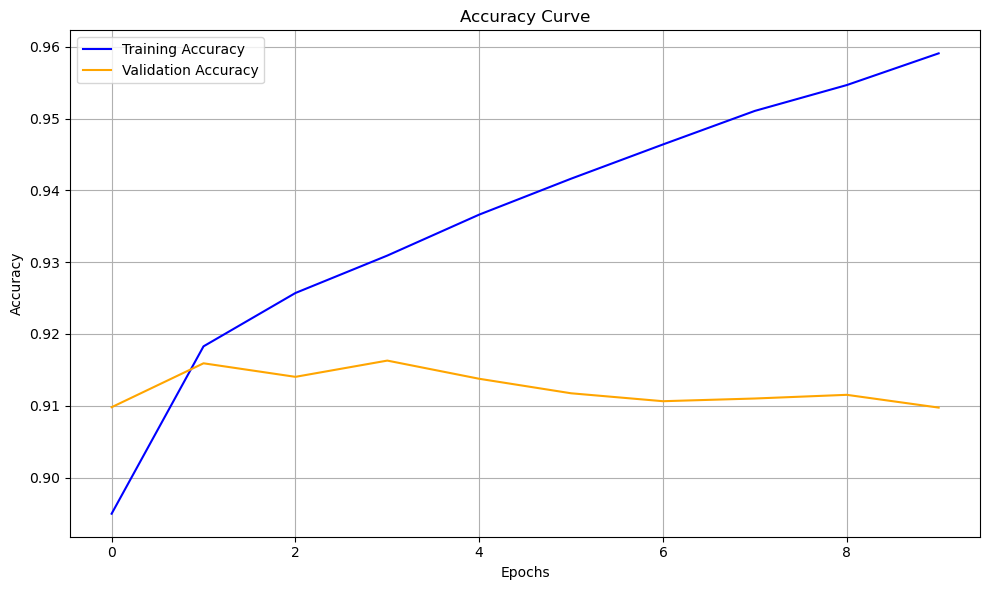

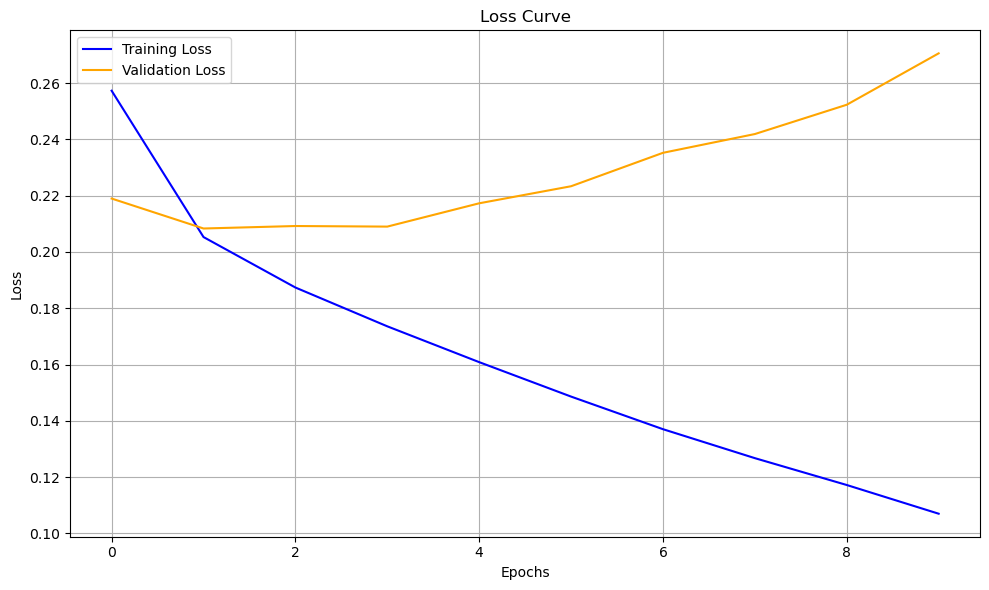

In [13]:
import matplotlib.pyplot as plt

# Plotting Accuracy Curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
